# 05 Result Analysis

Local notebook for post-training metrics/table/figure analysis.

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
OUT = Path(r"C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1")
print('OUT:', OUT)

OUT: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1


In [8]:
model_cmp = pd.read_csv(OUT / 'tables' / 'model_comparison_metrics.csv')
trade_stats = pd.read_csv(OUT / 'tables' / 'trade_statistics.csv')
wf = pd.read_csv(OUT / 'tables' / 'walk_forward_results.csv')

display(model_cmp.sort_values('sharpe_ratio', ascending=False))
display(trade_stats)
display(wf.head())

,model,total_return,sharpe_ratio,max_drawdown,profit_factor
0,ema_cross_32_96,0.528682,1.328384,-0.181282,0.551918
1,macd_32_96,0.528682,1.328384,-0.181282,0.551918
2,macd_8_24,-0.281129,-0.688592,-0.504754,0.195435
3,ema_cross_8_24,-0.281129,-0.688592,-0.504754,0.195435
4,ema_cross_16_48,-0.413764,-1.238416,-0.474299,0.325869
5,macd_16_48,-0.413764,-1.238416,-0.474299,0.325869
6,decoder_transformer,-0.335794,-1.582313,-0.375585,0.975367
7,long_only,-0.490045,-1.615284,-0.592907,0.686272
8,tsmom_78,-0.508217,-1.702558,-0.537906,0.199521
9,lstm_dmn,-0.120990,-1.733816,-0.202270,0.963049


,model,number_of_trades,turnover,average_net_pnl_points,percentage_time_long,percentage_time_short,percentage_time_flat
0,decoder_tft,55755,12965.725057,-0.016805,0.397142,0.470194,0.132664
1,decoder_transformer,53053,11166.879432,-0.009491,0.501359,0.316386,0.182255
2,ema_cross_16_48,3545,4602.000000,-0.008901,0.508479,0.445765,0.045755
3,ema_cross_32_96,2926,3402.000000,0.013077,0.537476,0.419920,0.042604
4,ema_cross_8_24,4697,6870.000000,-0.003992,0.494122,0.457088,0.048790
5,long_only,2400,2400.000000,-0.014252,0.959647,0.000000,0.040353
6,lstm_dmn,37980,4725.901952,-0.003701,0.256874,0.301129,0.441997
7,macd_16_48,3545,4602.000000,-0.008901,0.508479,0.445765,0.045755
8,macd_32_96,2926,3402.000000,0.013077,0.537476,0.419920,0.042604
9,macd_8_24,4697,6870.000000,-0.003992,0.494122,0.457088,0.048790


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,hit_rate,profit_factor,average_trade_pnl,average_win,average_loss,win_loss_ratio,number_of_trades,turnover,window,model
0,-0.125649,-0.701088,0.367450,-3.286418,-3.820046,-0.162033,-4.326829,0.465105,0.680073,-0.237639,2.068722,-0.982771,2.104989,258,258.0,wf_1_2021-07-01_2021-12-31,long_only
1,-0.102449,-0.615872,0.373596,-2.560977,-3.668982,-0.168346,-3.658357,0.426954,0.115616,-1.369811,1.593065,-1.745049,0.912906,1112,1846.0,wf_1_2021-07-01_2021-12-31,tsmom_12
2,-0.107372,-0.635649,0.371886,-2.714892,-3.860948,-0.213374,-2.979035,0.428195,0.121205,-1.302271,1.484252,-1.685898,0.880393,909,1486.0,wf_1_2021-07-01_2021-12-31,tsmom_24
3,-0.012711,-0.051699,0.370122,-0.143421,-0.201349,-0.110188,-0.469188,0.445720,0.214546,-1.150436,1.962400,-1.743933,1.125272,612,922.0,wf_1_2021-07-01_2021-12-31,tsmom_48
4,-0.099839,-0.605662,0.369937,-2.515402,-3.429826,-0.146987,-4.120512,0.455800,0.192590,-1.129903,1.770640,-1.650669,1.072680,565,840.0,wf_1_2021-07-01_2021-12-31,tsmom_78


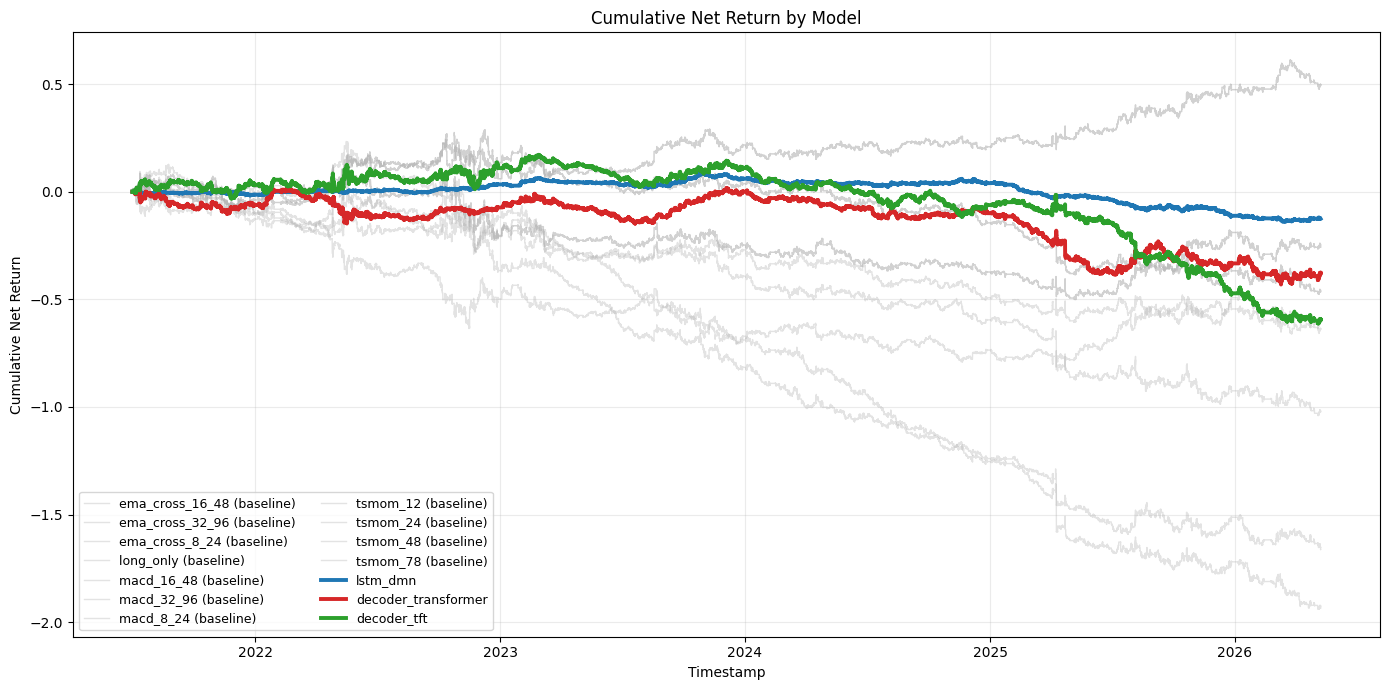

In [9]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',            # blue
    'decoder_transformer': '#d62728', # red
    'decoder_tft': '#2ca02c',         # green
}

plt.figure(figsize=(14, 7))

# plot non-focus first (background)
for model_name, g in pred.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

# plot focus on top
for model_name in focus_models:
    g = pred[pred['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color=focus_colors.get(model_name, None),
        linewidth=2.8, alpha=1.0,
        label=model_name
    )

plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

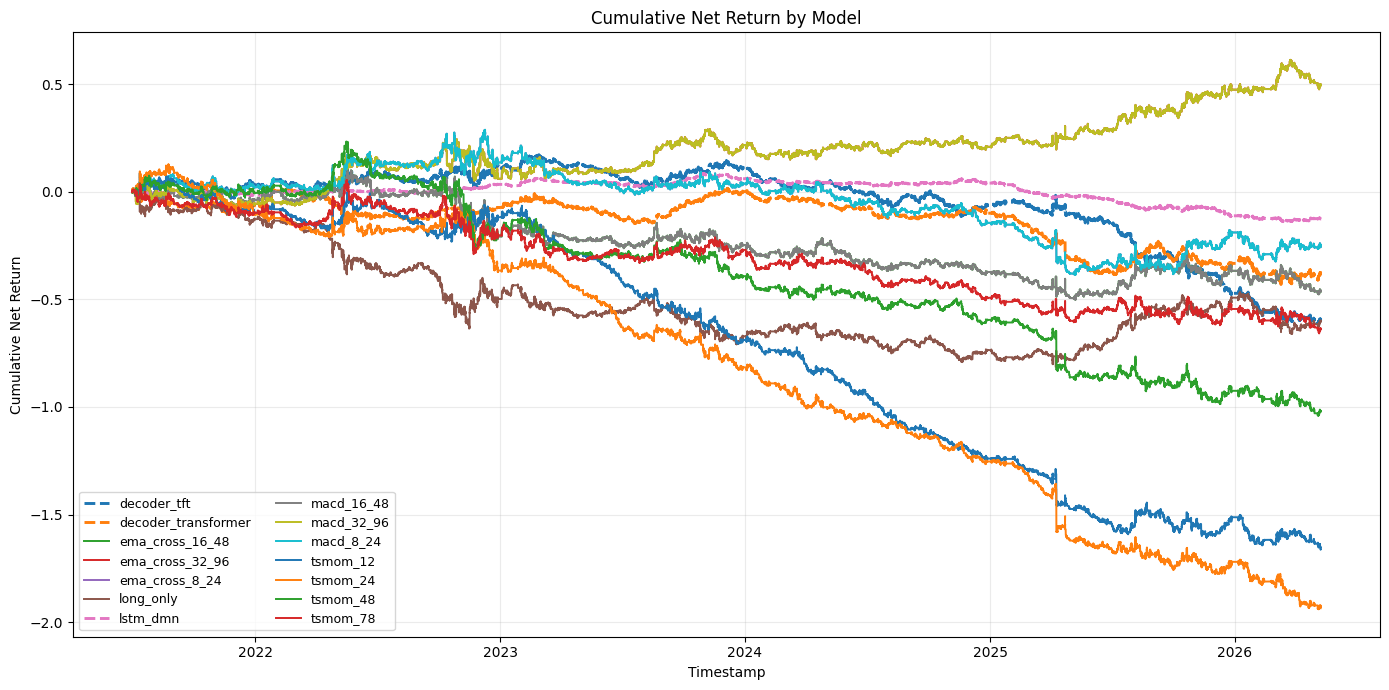

In [10]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = {'lstm_dmn', 'decoder_transformer', 'decoder_tft'}

plt.figure(figsize=(14, 7))
for model_name, g in pred.groupby('model'):
    ls = '--' if model_name in focus_models else '-'
    lw = 2.1 if model_name in focus_models else 1.4
    plt.plot(g['timestamp'], g['cum_net_return'], label=model_name, linewidth=lw, linestyle=ls)
plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

,days,mean_daily_cost,median_daily_cost,p95_daily_cost,max_daily_cost,total_cost
model,,,,,,
tsmom_12,1200,324139.785120,306662.440000,581171.882200,9.270826e+05,3.889677e+08
decoder_tft,1200,257577.148450,196528.126024,804611.383794,1.087831e+06,3.090926e+08
tsmom_24,1200,248594.952723,226140.870000,537500.353000,9.298204e+05,2.983139e+08
decoder_transformer,1200,214665.813957,195094.873424,473354.634117,7.995343e+05,2.575990e+08
tsmom_48,1200,157538.103097,98598.326000,436258.093400,9.018537e+05,1.890457e+08
tsmom_78,1200,133027.102633,86635.298000,370715.434400,7.722336e+05,1.596325e+08
macd_8_24,1200,132431.412440,122599.986000,274183.983200,5.315776e+05,1.589177e+08
ema_cross_8_24,1200,132431.412440,122599.986000,274183.983200,5.315776e+05,1.589177e+08
lstm_dmn,1200,92576.576704,80719.959714,209941.800416,3.474121e+05,1.110919e+08


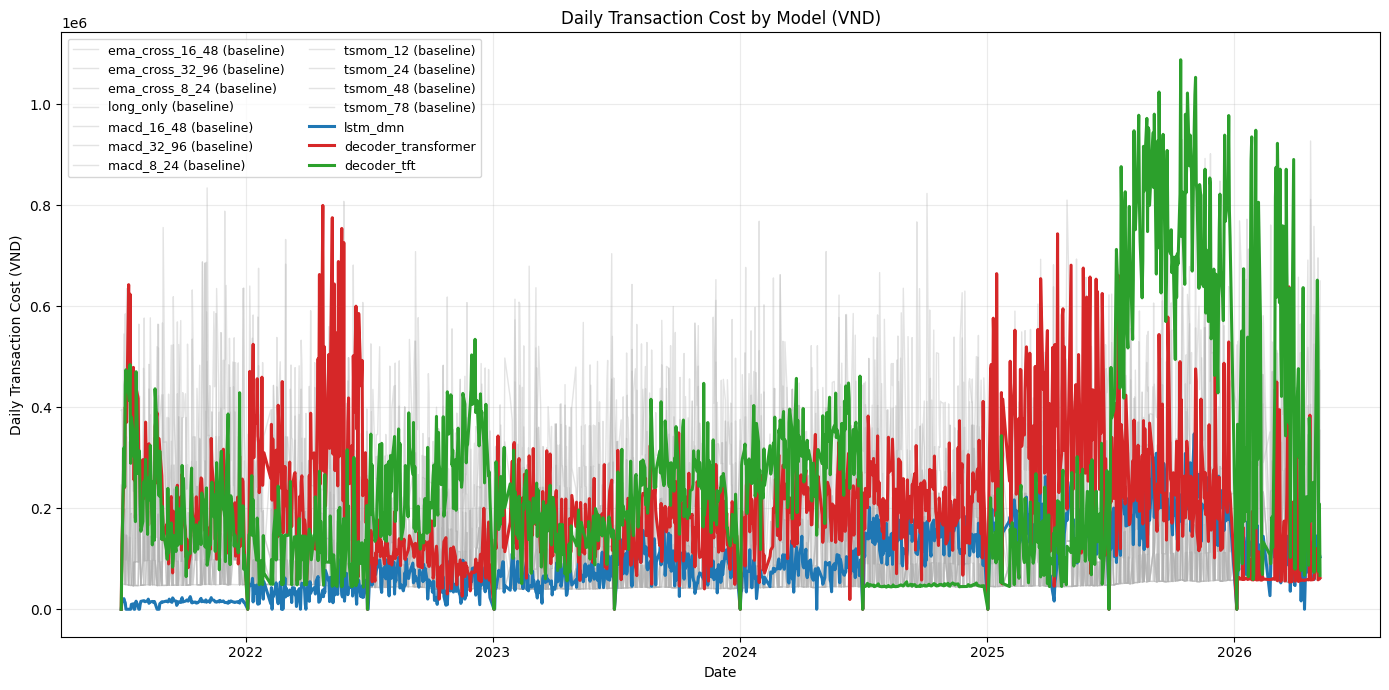

In [11]:
import numpy as np
from pathlib import Path

if 'PROJ' not in globals():
    if 'OUT' in globals():
        PROJ = OUT.parents[1]
    else:
        PROJ = Path.cwd().resolve().parent

px = pd.read_parquet(PROJ / 'data' / 'features' / 'features_5min.parquet')[['timestamp', 'close']]
cost_df = pred[['timestamp', 'model', 'position']].merge(px, on='timestamp', how='left')
cost_df = cost_df.sort_values(['model', 'timestamp']).copy()

contract_multiplier = 100000
margin_rate = 0.1848
transfer_tax_rate = 0.001
fixed_fee_per_side = 5000 + 2700 + 2700

cost_df['prev_pos'] = cost_df.groupby('model')['position'].shift(1).fillna(0.0)
cost_df['buy_units'] = (cost_df['position'] - cost_df['prev_pos']).clip(lower=0.0)
cost_df['sell_units'] = (cost_df['prev_pos'] - cost_df['position']).clip(lower=0.0)

cost_df['tax_vnd_per_contract'] = (
    margin_rate * contract_multiplier * transfer_tax_rate * cost_df['close'] / 2.0
)
cost_df['buy_cost_vnd'] = cost_df['buy_units'] * fixed_fee_per_side
cost_df['sell_fixed_cost_vnd'] = cost_df['sell_units'] * fixed_fee_per_side
cost_df['sell_tax_cost_vnd'] = cost_df['sell_units'] * cost_df['tax_vnd_per_contract']
cost_df['tx_cost_vnd'] = cost_df['buy_cost_vnd'] + cost_df['sell_fixed_cost_vnd'] + cost_df['sell_tax_cost_vnd']
cost_df['date'] = cost_df['timestamp'].dt.date

daily_cost = cost_df.groupby(['model', 'date'], as_index=False)['tx_cost_vnd'].sum()
daily_cost_stats = (
    daily_cost.groupby('model')['tx_cost_vnd']
    .agg(
        days='count',
        mean_daily_cost='mean',
        median_daily_cost='median',
        p95_daily_cost=lambda s: s.quantile(0.95),
        max_daily_cost='max',
        total_cost='sum',
    )
    .sort_values('total_cost', ascending=False)
)

display(daily_cost_stats)

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',
    'decoder_transformer': '#d62728',
    'decoder_tft': '#2ca02c',
}

daily_cost = daily_cost.sort_values(['model', 'date'])
daily_cost['date'] = pd.to_datetime(daily_cost['date'])

plt.figure(figsize=(14, 7))
for model_name, g in daily_cost.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

for model_name in focus_models:
    g = daily_cost[daily_cost['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color=focus_colors.get(model_name, None),
        linewidth=2.2, alpha=1.0,
        label=model_name
    )

plt.title('Daily Transaction Cost by Model (VND)')
plt.xlabel('Date')
plt.ylabel('Daily Transaction Cost (VND)')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [12]:
fig_path = OUT / 'figures' / 'model_cumulative_returns.png'
print('Saved figure exists:', fig_path.exists(), fig_path)

Saved figure exists: True C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\figures\model_cumulative_returns.png
